# The Network Common Data Format: netCDF

NetCDF is one of the most common ways that geoscience data is distributed. It was developed in the early 1990s specifically to deal with the challenges associated with multidimensional arrays. 

Much of the climate/earth/ocean/atmosphere data that you can access will be in the form of netCDF files. They typically have the extention`.nc`, so like `ocean_temps.nc`.

NetCDF files are machine independant, meaning that macs, PCs, linux machines, you name it, they can all read the files. 

Also, the netCDF files are self contained - i.e. they carry all the information about the data they contain with them. So they are 'self-describing' like the datasets and dataArrays we have been building. 

In fact, Xarray is bascially a package devoted to reading, writing, and manipulating netCDFs. This means it's a super easy and useful way to work with geophysical data from nearly anywhere. 

In this lesson we are going to use Xarray to load some Sea Surface Temperature data from a netCDF file. We will see how easy it is to make calculations and plots of these big data sets using Xarray.

### credit 

This lesson is from  Abernathy's book: (https://earth-env-data-science.github.io/lectures/xarray/xarray_intro.html). 


# Loading netCDF datasets

The primary tool in the Xarray library that we will use with netCDF files is `xr.open_dataset()`. This will read in a netCDF file and create one of our DataArrays. 

In this example we are going to read in a Sea Surface Temperature dataset created by NOAA that goes back to the 1800's. You can learn more about the data here: https://www.ncdc.noaa.gov/data-access/marineocean-data/extended-reconstructed-sea-surface-temperature-ersst-v5

First, let's do our normal import statements that we need to access the libraries in this new notebook:


In [5]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Let's load in the data using `xr.open_dataset()` and take a look at it:

In [6]:


url = 'http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc'
ds = xr.open_dataset(url, drop_variables = ['time_bnds'])
ds

# So this is a 3 dimensional dataset, with time, lat, and lon. 
# I visualize a cube right now 
# Since the dimensions are time, lat, lon, its actually inverted from traditional cartesian coordinates
# So if this were a function of f(x, y, z), then definining the dimensions on the computer with python would be 
# f(z, y, z), meaning that time corresponds to the z axis, lat to the y axis, lon to the x axis.


<xarray.Dataset> Size: 133MB
Dimensions:  (time: 2069, lat: 89, lon: 180)
Coordinates:
  * time     (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-05-01
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Data variables:
    sst      (time, lat, lon) float32 133MB ...
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

In [7]:

ds = xr.open_dataset("/home/matthew7mendoza/Programming/spear-esm-data-automation/Learning/argo_float_data.nc", drop_variables = ['time_bnds'])

ds

# This cell will not run on my personal computer because I don't have the file on my computer, so getting the 
# data from the web is better. 

OSError: [Errno -101] NetCDF: HDF error: '/home/matthew7mendoza/Programming/spear-esm-data-automation/Learning/argo_float_data.nc'

Did that work? There is a lot of information there. Let's go through all of it to make sure we understand what our Dataset looks like. 

Draw on the board and answer the following:
* What are the dimensions of the data?
* What is the data itself
* what do the coordinate of the dimensions look like?
* draw a schematic of the data and label all the 'sides'
* what is the stuff in the attributes?


# plotting netcdf data

Next let's make some plots to look at the data. We have lat, lon, Sea Surface Temperature data over a range of times. Maybe let's start with a simple plot of the SST all over the globe on one particular day. What is a good day?

*note* if you look at the time dimension, we see that the data is reported in monthly means with dates on the first of the month - let's pick the first day of a month.

In [ ]:
%whos

Variable   Type       Data/Info
-------------------------------
ds         Dataset    <xarray.Dataset> Size: 13<...>nlimited_Dimension:  time
np         module     <module 'numpy' from '/ho<...>kages/numpy/__init__.py'>
pd         module     <module 'pandas' from '/h<...>ages/pandas/__init__.py'>
plt        module     <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
url        str        http://www.esrl.noaa.gov/<...>aa.ersst.v5/sst.mnmean.nc
xr         module     <module 'xarray' from '/h<...>ages/xarray/__init__.py'>


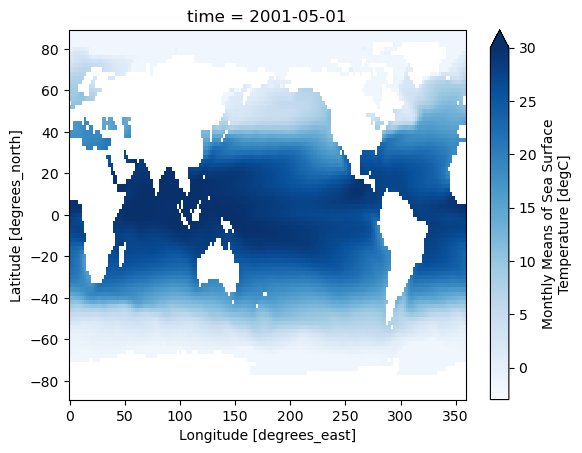

In [ ]:
ds.sst.sel(time = '2001-05-01').plot(vmin = -3, vmax = 30, cmap = 'Blues');
#ds.sst.sel(time = '2001-05-01').plot(vmin = -3, vmax = 30);


#.sel is select 
# sst means sea surface temperature, its the data that's found in the netCDF file: 
# url = 'http://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/noaa.ersst.v5/sst.mnmean.nc'

# The date we're looking at is may 1st, 2001

what if we pick a different day of the month?


In [ ]:
ds.sst.sel(time = '2001-05-02').plot(vmin = -3, vmax = 30);


# So it crashes because the day 2 doesnt have anything for may 2001

KeyError: "not all values found in index 'time'. Try setting the `method` keyword argument (example: method='nearest')."

We got an error because we asked for a specific day that isn't in the dataset. We can get around this sort of thing luckily!


### Nearest point indexing, or 'nearest neighbor lookups'

In the case above we input an exact date that is avilabile in our data. What if we didn't know all the exact dates? Try putting a random date in to the plot call.  What if we want to get the time closest to some date we care about? Xarray can handle this if we give it an extra arguement using `method='nearest'`:

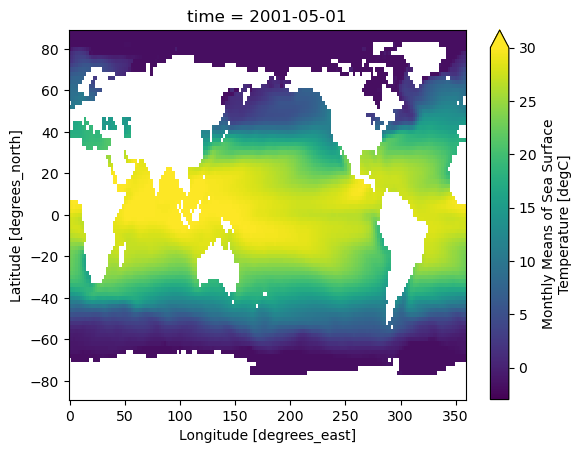

In [ ]:
ds.sst.sel(time = '2001-05-02', method = 'nearest').plot(vmin = -3, vmax = 30);

# Alright the parameter method = "nearest" just makes it so that the program will not crash if we dont have the thing there. 
# Turns out that the nearest is just the first day! 

Ok, so we can pretty easily make a plot of global SST on a single day. That is pretty cool. 

We can use this dataset to see some amazing things without doing a lot of hard work thanks to the people who developed xarray (and the people who created/collected the data!!!!!).




### Let's make a simple plot to see how global average sea surface temperature has changed over time. Do you think we will be able to see a warming signal?

To do this we want to use xarray's `.mean()` function. But we need to tell it what kind of mean we want. In other words we need to define the dimensions over which to take the mean. If we are interested in makeing a plot that shows global averaged sea surface temperature over time, what are the dimentions to average over?

we are going to do something like: `ds.sst.mean( dim = ('dim1', ...) ).plot()` fill in the blanks:

ERR: curl error: Stream error in the HTTP/2 framing layer
ERR: DAP DATADDS packet is apparently too short


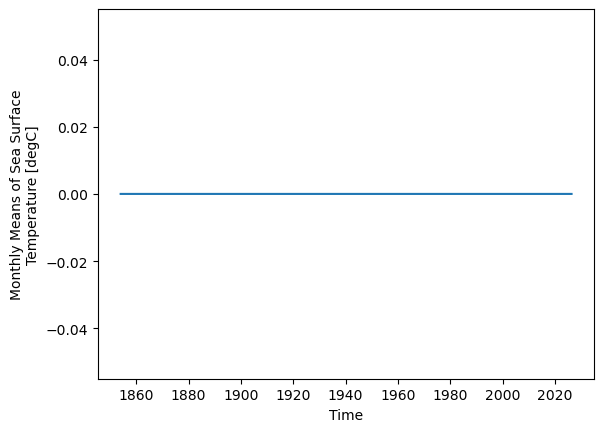

In [ ]:
ds.sst.mean( dim = ('lat', 'lon'), skipna = True).plot();

# So x array is going to take the mean of all the sea surfacr temperature with resepect to lat and lon
# However when I plot this I get a straight line
# It's because the sst data array includes data about the land, and obviously land is not going to have a sea surface temperature
# it's not sea!
# It's land, thus, there are going to be sonme NaN values
# Any int, float, ect... + NaN = NaN. So we gotta ignore NaN.s then.

# the parameter skipna = True will fix this issue, it will skip all the NaN values 



# This is a challenge, the file is not working for some reason, I'm just going to leave it be for now and come back
# I understand the core concept of the methods and what's going on under the hood, it would be a waste of time for me to continue to debug this file issue


What about just plotting the time average map of SST? What dimensions are we going to average over here?

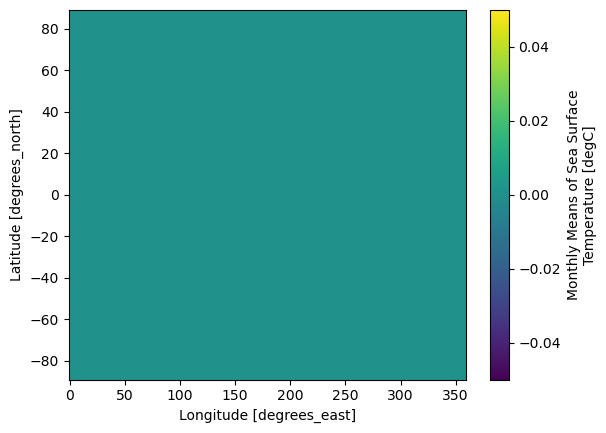

In [ ]:
ds.sst.mean(dim = ('time')).plot();


# A similar issue here, something is going on with the dataset

# However we're going into the dataset, we're accessing the specific DataArray called SST and then we look for the dimension of time, and plot everything on that axes


What about the average temperature as a function of latitude? We want to make a line plot that shows how temperature depends on latitude only, how would we do that?


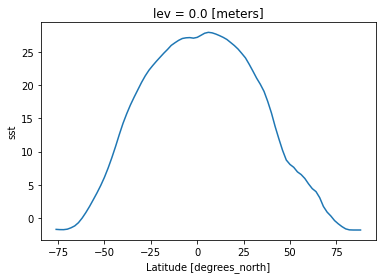

In [ ]:
ds.sst.mean(dim = ('lon', 'time')).plot();

# By taking the mean of the longitude and time, you're projecting the curve onto the latitutude plane
# You take the area divided by the # of points, gets you the average. Since you're doing that for lon and time only, those indepedndant variables
# dissapear and you're only left with lat left. 

# Then you have your function of latitude. 

How about a timeseries of temperature at a single point? Let's make a plot of the SST at 45 degrees north, and 230 degrees. How do we do that? Recall the `.sel()` method, and it's arguement `nearest`

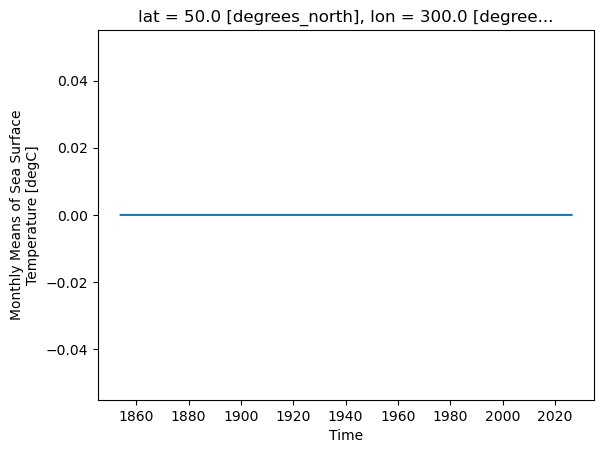

In [ ]:
ds.sst.sel(lon = 300, lat = 50, method = 'nearest').plot()

that is a mess. Let's adjust the axis so we can see what is happening in that blue mess. Let's pick 20 years of data, from 1980 to 2000 and zoom in. We can do this by setting the range of the x axis. We are going to build up a lot of tricks to make plots look the way we want. This is one. 

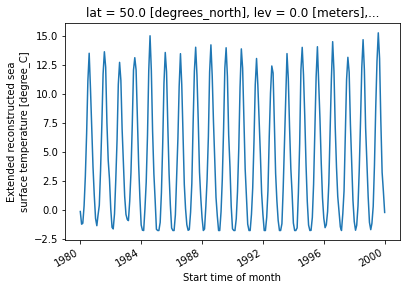

In [ ]:
ds.sst.sel(time = slice('1980-01-01', '2000-01-01'), lon = 300, lat = 50).plot()

# Looking at the 20 year time period. All of this selectrion is basically slicing the sort of data that you want


Huh. That's cool. What are we seeing here?

Let's plot two different Latitudes, one high lat and one on the equator:

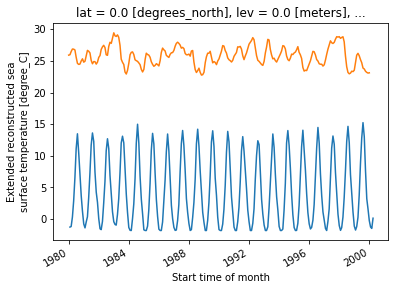

In [ ]:
#ds.sst.sel(lon = 300, lat = 50 and lon = 100, lat = 0).plot()
ds.sst.sel(lon=300, lat=50, time = slice('1980-01-03', '2000-04-05')).plot()
ds.sst.sel(lon=230,lat=0,time = slice('1980-01-01', '2000-01-01')).plot();

# Interesting, so I can see that the positions of the arguments for select dont really matter. 



# Groupby
Yep, we can do groupby here too.

Let's groupby month and apply a mean. This will give us a climatology of SST from the past couple hundered years at every point on the globe:

In [ ]:
gb = ds.groupby('time.month')
ds_mn = gb.mean(dim = 'time')

# Okay so what this is doing its like its going to take that massive DataSet and it's going to group by month 
# First time is the smart object in the specific time format for python 
# Then since you're looking for month within time 
# and its a smart object python is going to know to group by the months, so that's exactly what it does here 

# Then for ds_mn when you have all the months groupped up what this does is it a averages all twelve of those months with respect to time 
# leaving only the lat and the lon left 




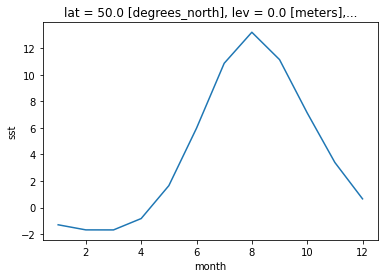

In [ ]:
ds_mn.sst.sel(lat=50,lon=300).plot();

# Now we plot 

climatology at a specific point in the North Atlantic:

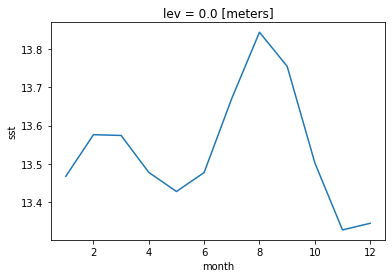

In [ ]:
ds_mn = gb.mean(dim=['time','lon','lat'])
ds_mn.sst.plot();

In [ ]:
ds_mn

<xarray.Dataset>
Dimensions:  (lev: 1, month: 12)
Coordinates:
  * lev      (lev) float64 0.0
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    sst      (month, lev) float32 13.47 13.58 13.57 13.48 ... 13.5 13.33 13.35
    ssta     (month, lev) float32 -0.2444 -0.242 -0.2388 ... -0.2258 -0.2397

Plot the July minus Jan differences

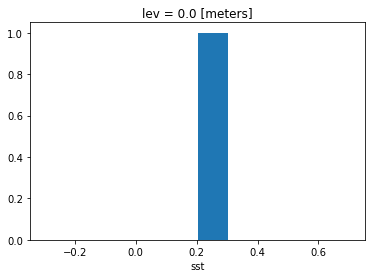

In [ ]:
seasonal_diff = ds_mn.sst.sel(month = 7) - ds_mn.sst.sel(month = 1)

seasonal_diff.plot();

### remove a time mean

Let's look more clearly at the long term SST trend by removing the seasonal climatology

In [11]:
gb = ds.groupby('time.month')
ds_anom = gb - gb.mean(dim='time')

ds_anom

ERR: curl error: Stream error in the HTTP/2 framing layer
ERR: DAP DATADDS packet is apparently too short


<xarray.Dataset> Size: 133MB
Dimensions:  (lat: 89, lon: 180, time: 2069)
Coordinates:
  * lat      (lat) float32 356B 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 720B 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-05-01
    month    (time) int64 17kB 1 2 3 4 5 6 7 8 9 10 ... 8 9 10 11 12 1 2 3 4 5
Data variables:
    sst      (time, lat, lon) float32 133MB 1.8 1.8 1.8 1.8 ... nan nan nan nan
Attributes: (12/39)
    climatology:                     Climatology is based on 1971-2000 SST, X...
    description:                     In situ data: ICOADS2.5 before 2007 and ...
    keywords_vocabulary:             NASA Global Change Master Directory (GCM...
    keywords:                        Earth Science > Oceans > Ocean Temperatu...
    instrument:                      Conventional thermometers
    source_comment:                  SSTs were observed by conventional therm...
    ...                              ...
    comment:                         SSTs were observed by conventional therm...
    summary:                         ERSST.v5 is developed based on v4 after ...
    dataset_title:                   NOAA Extended Reconstructed SST V5
    _NCProperties:                   version=2,netcdf=4.6.3,hdf5=1.10.5
    data_modified:                   2026-06-03
    DODS_EXTRA.Unlimited_Dimension:  time

timeseries of SST anomaly at a certain point:

In [10]:
ds_anom.sst.sel(lat = 50, lon = 300).plot();

NameError: name 'ds_anom' is not defined

## Saving data to netcdf

Suppose we are always working with the mean surface temperature. Here calculating the mean is fast, but suppose it were very slow... It would be useful to save the mean data so we don't have to repeat the calculation.

Xarray makes that very easy. In general it works like this: 

```python
name = "whatever.nc"
some_dataset.to_netcdf(name)
```

So lets try that for our data:

In [9]:
sst_mean = ds_anom

name = "sst_mean.nc"
sst_mean.to_netcdf(name)

NameError: name 'ds_anom' is not defined

In [ ]:
ds = open_dataset()

The end...

# Breakout / exercise 03